<a href="https://colab.research.google.com/github/tatahonon/cvNotebooks/blob/main/Homework31.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Prac 03. Part 1

For this homework you are going to implement the **unsharp masking** filter (USM). It is a technique to improve the sharpness of an image by combining the image with its blurred (unsharp) version. See the Wikipedia [page](https://en.wikipedia.org/wiki/Unsharp_masking) for more details.

### Unsharp Masking (USP)
The USM technique consists of the following steps:
* Load the image you will be working with.
* Create a blurred (unsharp) version of the original image.
* Add the unsharp image (with a certain **weight**) to the original.

To sum it up, the USM performs the following operation:

`sharpened = original + (original − unsharp) × amount`

Even though we provide you an image to work with, you are welcome to use your own images :-)

In [2]:
!wget  https://raw.githubusercontent.com/tatahonon/cvNotebooks/main/pic31.png

--2026-05-20 14:29:00--  https://raw.githubusercontent.com/tatahonon/cvNotebooks/main/pic31.png
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 736501 (719K) [image/png]
Saving to: ‘pic31.png’

pic31.png           100%[===================>] 719.24K  --.-KB/s    in 0.03s   

2026-05-20 14:29:01 (23.7 MB/s) - ‘pic31.png’ saved [736501/736501]



In [3]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
plt.rcParams['figure.figsize'] = [15, 10]

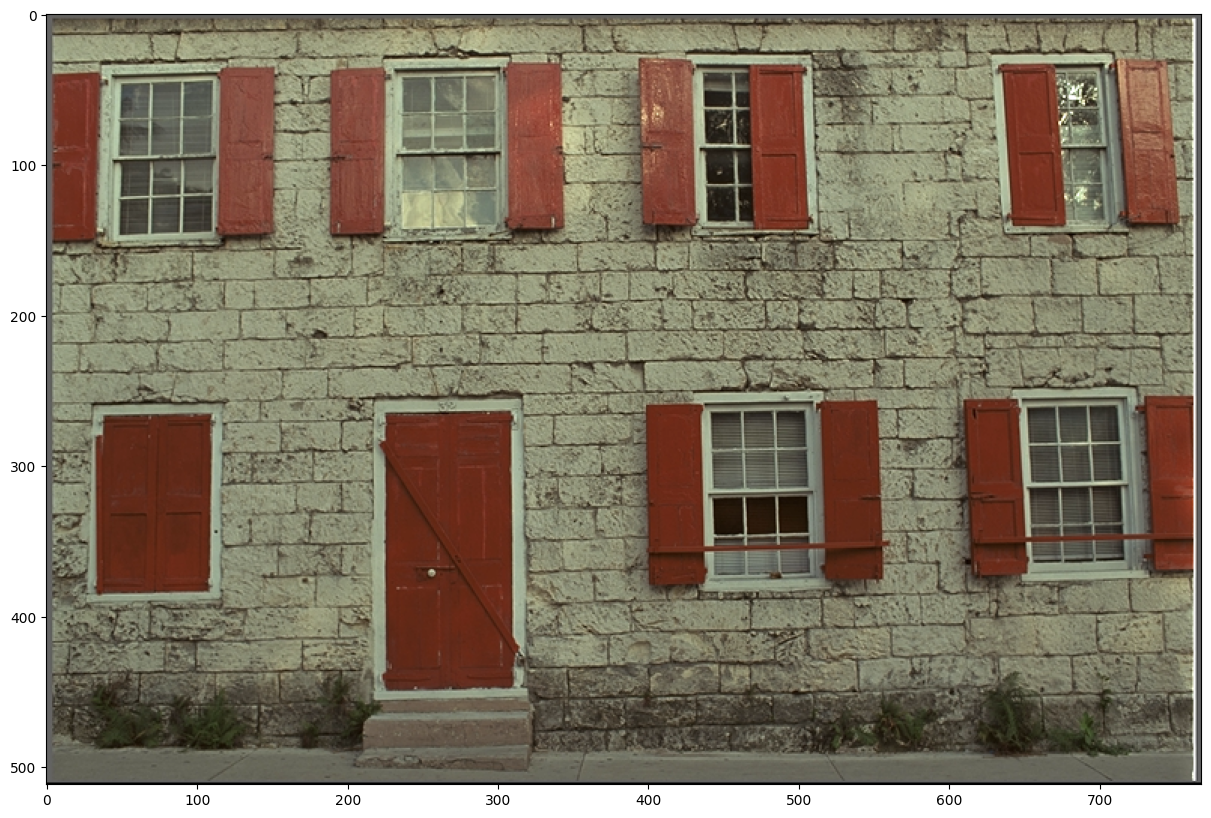

In [4]:
img = cv2.imread('pic31.png')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img)

In [5]:
# Create a blurred (unsharp) version of the original image (you can use Gaussian blurring)
unsharp =  cv2.GaussianBlur(img.astype(np.float32), (0, 0), sigmaX=2)

In [6]:
# Create the difference image (original − unsharp)
# Note: Remember that you are working with uint8 data types. Any addition or substractions
# might result in overflow or underflow, respectively. You can prevent this by casting the images to float.
diff = img.astype(np.float32) - unsharp

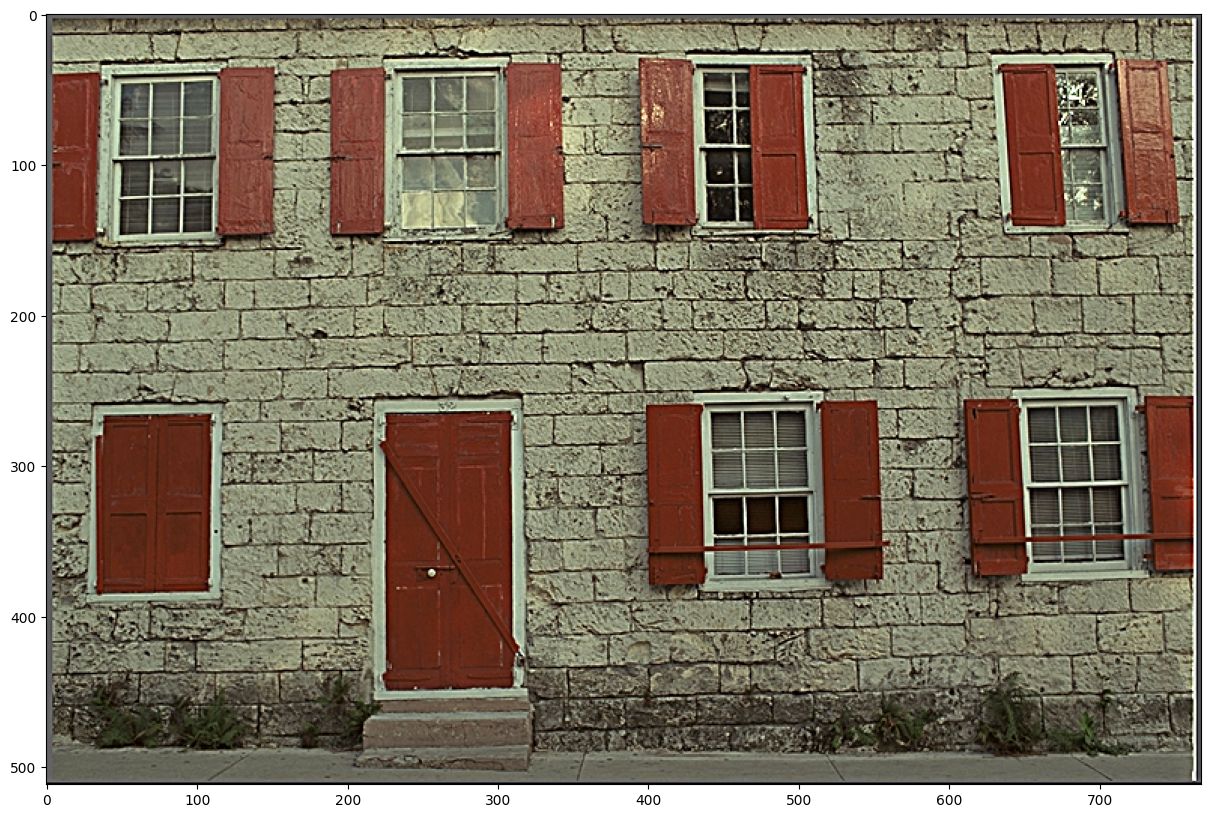

In [7]:
# Apply USM to get the resulting image using `sharpened = original + (original − unsharp) × amount`
# Note: Again, take care of underflows/overflows if necessary.
sharpened = np.clip(img.astype(np.float32) + diff * 1, 0, 255).astype(np.uint8)
plt.imshow(sharpened)

Questions
What is a good (reasonable) value for the amount parameter? For a natural result, 0.7 or 1.0
What happens if it is too small? If amount is too small, the sharpening effect will be very weak or almost invisible.
What happens if it is too large? If amount is too large, the image becomes over-sharpened.